In [13]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [14]:
NUM_QUBITS = 3
MARKED_ITEM = "101" # The item we want to find

Oracle Circuit:


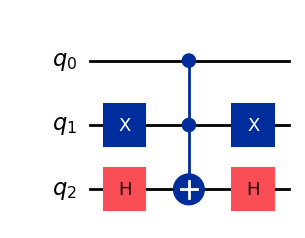

In [ ]:
from qiskit.circuit.library import MCXGate # Correct import

# The oracle "marks" the desired state by flipping its phase.
oracle = QuantumCircuit(NUM_QUBITS, name="Oracle")

# Flip the qubits corresponding to '0's in the marked_item
zero_indices = [i for i, bit in enumerate(MARKED_ITEM) if bit == '0']
if zero_indices:
    oracle.x(zero_indices)

# --- This is the H-MCX-H construction for a multi-controlled Z-gate ---
# 1. Apply Hadamard to the target qubit
oracle.h(NUM_QUBITS - 1)
# 2. Apply the Multi-Controlled X gate
num_controls = NUM_QUBITS - 1
oracle.append(MCXGate(num_controls), list(range(NUM_QUBITS)))
# 3. Apply Hadamard back to the target qubit
oracle.h(NUM_QUBITS - 1)
# --- End of construction ---

# Flip the '0' qubits back
if zero_indices:
    oracle.x(zero_indices)

print("Oracle Circuit:")
oracle.draw('mpl')


Diffuser Circuit:


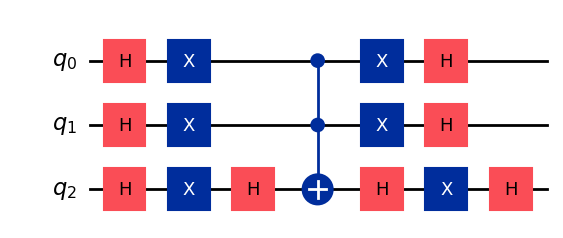

In [ ]:
from qiskit.circuit.library import MCXGate # Correct import

# The diffuser amplifies the amplitude of the marked state.
diffuser = QuantumCircuit(NUM_QUBITS, name="Diffuser")
diffuser.h(range(NUM_QUBITS))
diffuser.x(range(NUM_QUBITS))

# --- Apply the multi-controlled Z-gate (H-MCX-H) ---
diffuser.h(NUM_QUBITS - 1)
num_controls = NUM_QUBITS - 1
diffuser.append(MCXGate(num_controls), list(range(NUM_QUBITS)))
diffuser.h(NUM_QUBITS - 1)
# --- End of construction ---

diffuser.x(range(NUM_QUBITS))
diffuser.h(range(NUM_QUBITS))

print("\nDiffuser Circuit:")
diffuser.draw('mpl')


Optimal number of iterations: 2

Full Grover Circuit:


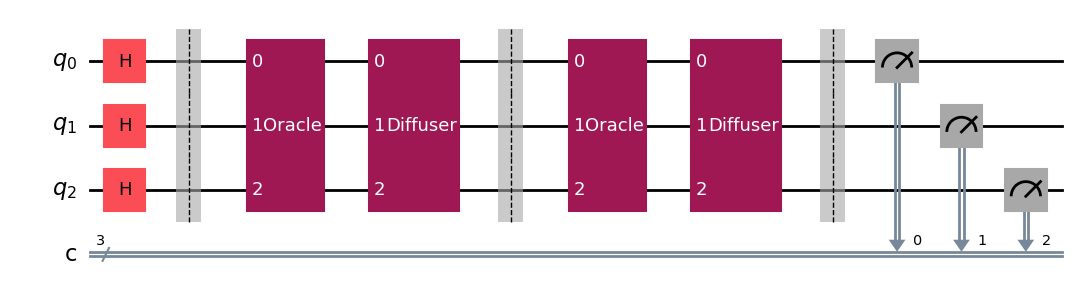

In [17]:
# Calculate optimal number of iterations
num_iterations = int(np.floor(np.pi / 4 * np.sqrt(2**NUM_QUBITS)))
print(f"\nOptimal number of iterations: {num_iterations}")

# Create the full circuit
grover_circuit = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
grover_circuit.h(range(NUM_QUBITS)) # Initial superposition
grover_circuit.barrier()

# Apply Grover iterations
for _ in range(num_iterations):
    grover_circuit.append(oracle.to_gate(), range(NUM_QUBITS))
    grover_circuit.append(diffuser.to_gate(), range(NUM_QUBITS))
    grover_circuit.barrier()

grover_circuit.measure(range(NUM_QUBITS), range(NUM_QUBITS))

print("\nFull Grover Circuit:")
grover_circuit.draw('mpl', style='iqx')


Simulation Results:


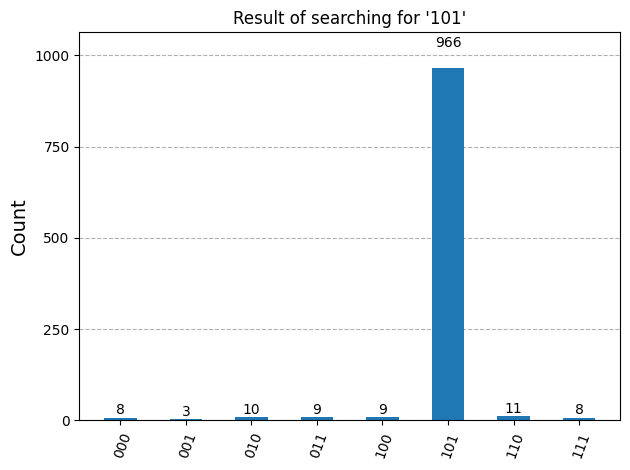

In [ ]:
# DECOMPOSE THE CIRCUIT: Break down the custom 'Oracle' and 'Diffuser' gates
# into fundamental gates that the simulator understands.
decomposed_circuit = grover_circuit.decompose()

# Now, run the DECOMPOSED circuit
backend = AerSimulator()
job = backend.run(decomposed_circuit, shots=1024) # Use the decomposed circuit here
result = job.result()
counts = result.get_counts() # No need to pass the circuit object here in modern Qiskit

print("\nSimulation Results:")
plot_histogram(counts, title=f"Result of searching for '{MARKED_ITEM}'")